In [1]:
import pandas as pd

df = pd.read_csv("/content/telco_customer_churn_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,MonthlyRevenue,RevenuePerTenureMonth
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-6 Months,29.85,29.850000
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,0,25-48 Months,56.95,55.573529
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-6 Months,53.85,54.075000
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48 Months,42.30,40.905556
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-6 Months,70.70,75.825000


# CORE KPI's

In [2]:
total_customers = df["customerID"].nunique()
churned_customers = df["Churn"].sum()
churn_rate = df["Churn"].mean() * 100
retained_customers = total_customers - churned_customers

total_revenue = df["TotalCharges"].sum()
avg_monthly_charge = df["MonthlyCharges"].mean()

total_customers, churned_customers, churn_rate, retained_customers, total_revenue, avg_monthly_charge

(7043,
 np.int64(1869),
 np.float64(26.536987079369588),
 np.int64(5174),
 np.float64(16056168.7),
 np.float64(64.76169246059918))

In [3]:
df.groupby("TenureGroup")["Churn"].mean().mul(100).round(2)

,Churn
TenureGroup,
0-6 Months,52.94
13-24 Months,28.71
25-48 Months,20.39
49-72 Months,9.51
7-12 Months,35.89


CHURN RATE BY TENURE BAR GRAPH

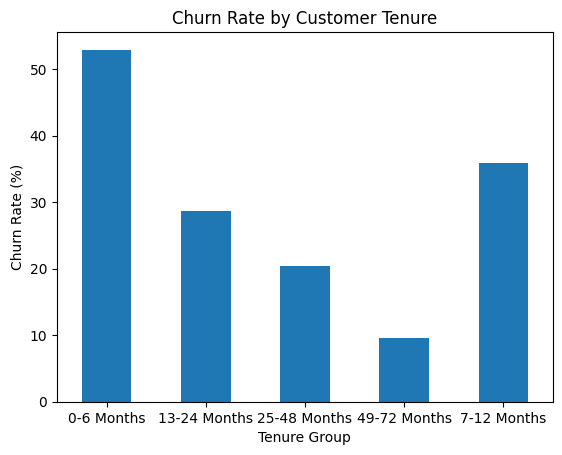

In [4]:
import matplotlib.pyplot as plt

churn_by_tenure = df.groupby("TenureGroup")["Churn"].mean().mul(100)

churn_by_tenure.plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [5]:
df.groupby("Contract")["Churn"].mean().mul(100).round(2)

,Churn
Contract,
Month-to-month,42.71
One year,11.27
Two year,2.83


# Churn by contract type

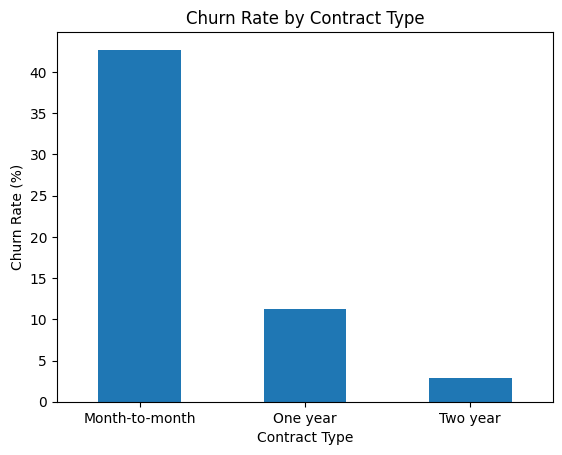

In [6]:
df.groupby("Contract")["Churn"].mean().mul(100).plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

# Churn by payment method

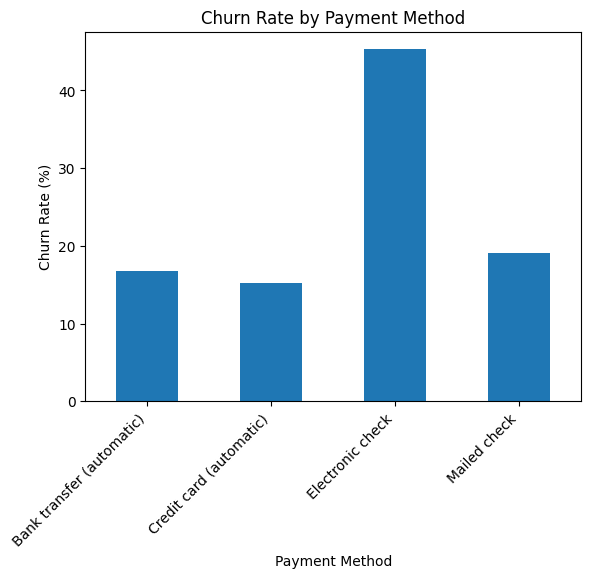

In [7]:
df.groupby("PaymentMethod")["Churn"].mean().mul(100).round(2)
df.groupby("PaymentMethod")["Churn"].mean().mul(100).plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

# Churn by Internet Service

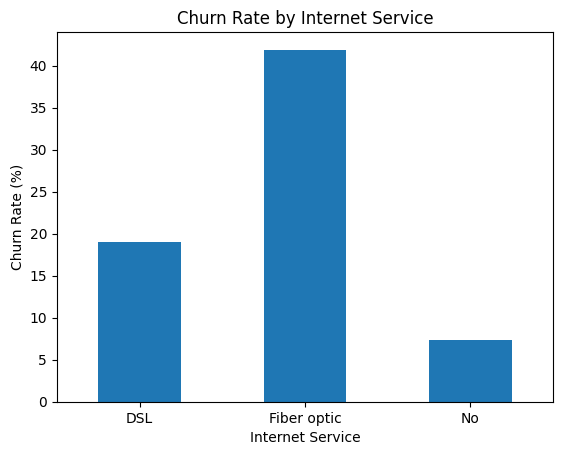

In [8]:
df.groupby("InternetService")["Churn"].mean().mul(100).round(2)
df.groupby("InternetService")["Churn"].mean().mul(100).plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()